In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# 0. GLOBAL THEME SETTING (Seaborn VIP Theme)
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

df = pd.read_csv("SuperMarket Analysis.csv")

C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_12084\832208586.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product line', y='Sales', ax=ax3, palette='Set2')


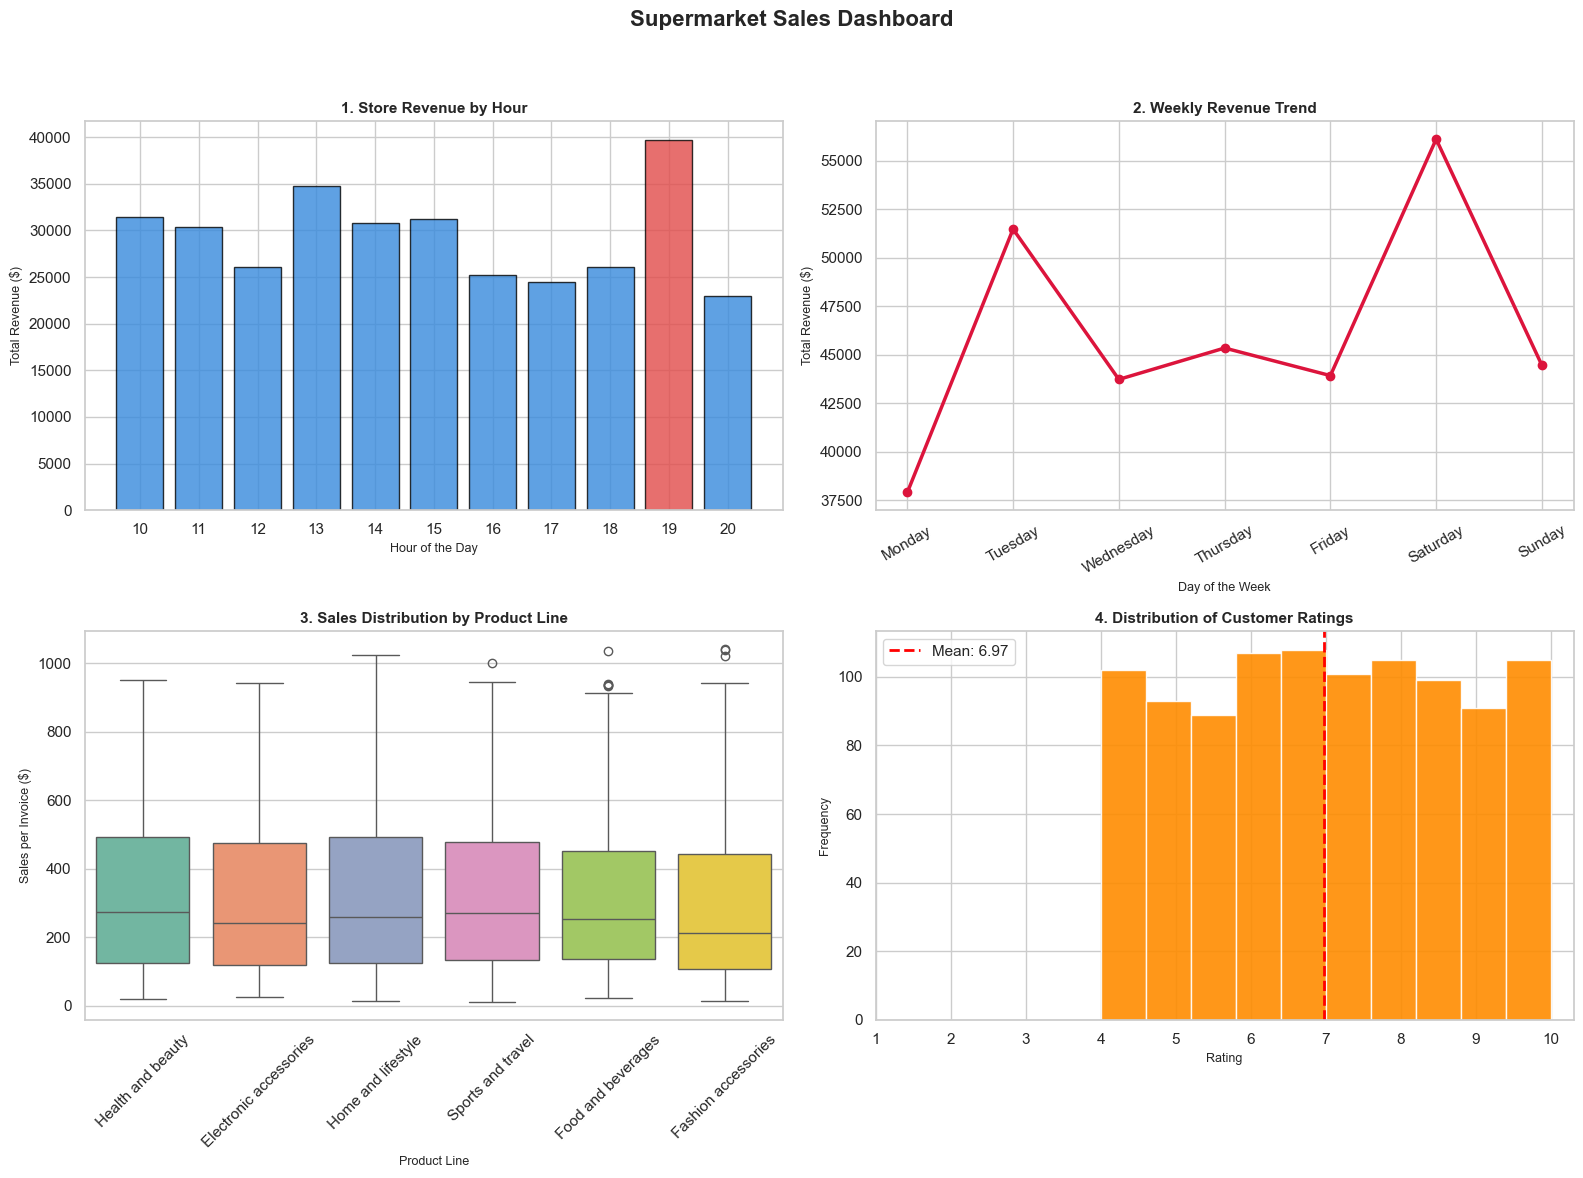

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Global theme
sns.set_theme(style='whitegrid')

# --- DATA PREPARATION ---
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour
hourly_revenue = df.groupby('Hour')['Sales'].sum()
peak_hour = hourly_revenue.idxmax()
bar_colors = ['#E24B4A' if h == peak_hour else '#378ADD' for h in hourly_revenue.index]

df['Day_of_Week'] = pd.to_datetime(df['Date']).dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_revenue = df.groupby('Day_of_Week')['Sales'].sum().reindex(day_order)

# --- DASHBOARD LAYOUT (2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
(ax1, ax2), (ax3, ax4) = axes

# 🌟 MAIN SUPER TITLE: Yeh poore board ke upar lagega
fig.suptitle('Supermarket Sales Dashboard', fontsize=16, fontweight='bold', y=0.98)


# CHART 1: Hourly Sales (Top-Left)
ax1.bar(x=hourly_revenue.index, height=hourly_revenue.values, color=bar_colors, edgecolor='black', alpha=0.8)
ax1.set_title('1. Store Revenue by Hour', fontsize=11, fontweight='bold')
ax1.set_xlabel('Hour of the Day', fontsize=9)
ax1.set_ylabel('Total Revenue ($)', fontsize=9)
ax1.set_xticks(hourly_revenue.index)

#  CHART 2: Weekly Sales (Top-Right)
ax2.plot(daily_revenue.index, daily_revenue.values, marker='o', color='crimson', linewidth=2.5)
ax2.set_title('2. Weekly Revenue Trend', fontsize=11, fontweight='bold')
ax2.set_xlabel('Day of the Week', fontsize=9)
ax2.set_ylabel('Total Revenue ($)', fontsize=9)
ax2.tick_params(axis='x', rotation=30)

#  CHART 3: Sales by Product Line (Bottom-Left)
sns.boxplot(data=df, x='Product line', y='Sales', ax=ax3, palette='Set2')
ax3.set_title('3. Sales Distribution by Product Line', fontsize=11, fontweight='bold')
ax3.set_xlabel('Product Line', fontsize=9)
ax3.set_ylabel('Sales per Invoice ($)', fontsize=9)
ax3.tick_params(axis='x', rotation=45)

#  CHART 4: Ratings (Bottom-Right)
ax4.hist(df['Rating'], bins=10, color='darkorange', edgecolor='white', alpha=0.9)
ax4.axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['Rating'].mean():.2f}")
ax4.set_title('4. Distribution of Customer Ratings', fontsize=11, fontweight='bold')
ax4.set_xlabel('Rating', fontsize=9)
ax4.set_ylabel('Frequency', fontsize=9)
ax4.set_xticks(range(1, 11))
ax4.legend(loc='upper left')


# --- CRITICAL ADJUSTMENT FOR SUPTITLE ---
# rect=[0, 0, 1, 0.95] ka matlab hai subplots ko 95% oonchai tak rakho, baaki 5% suptitle ke liye chor do
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save and Show
plt.savefig('supermarket_main_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_12084\1270964146.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product line', y='Sales', ax=ax3, palette='Set2')


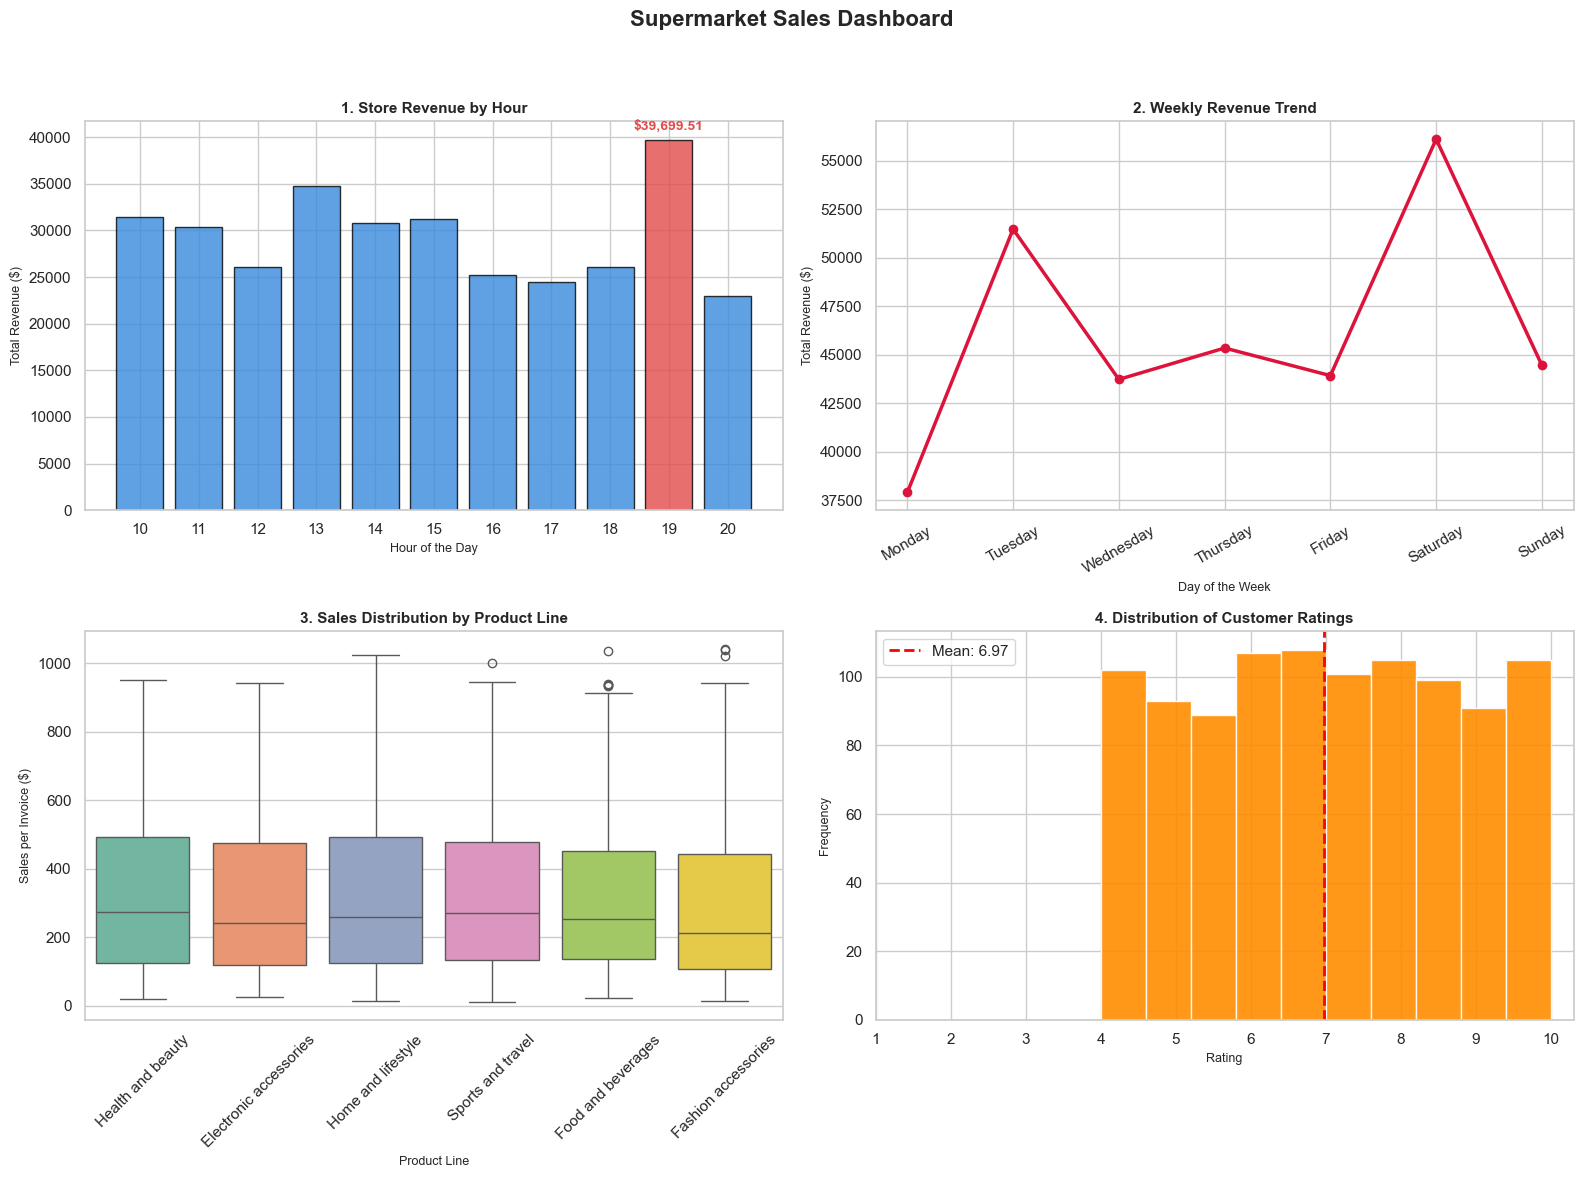

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Global theme
sns.set_theme(style='whitegrid')

# --- DATA PREPARATION ---
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour
hourly_revenue = df.groupby('Hour')['Sales'].sum()
peak_hour = hourly_revenue.idxmax()

# 🌟 NEW: Peak bar ki asli sales value nikalna annotation ke liye
peak_val = hourly_revenue.max()

bar_colors = ['#E24B4A' if h == peak_hour else '#378ADD' for h in hourly_revenue.index]

df['Day_of_Week'] = pd.to_datetime(df['Date']).dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_revenue = df.groupby('Day_of_Week')['Sales'].sum().reindex(day_order)

# --- DASHBOARD LAYOUT (2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
(ax1, ax2), (ax3, ax4) = axes

# MAIN SUPER TITLE
fig.suptitle('Supermarket Sales Dashboard', fontsize=16, fontweight='bold', y=0.98)


# 📊 CHART 1: Hourly Sales (Top-Left)
ax1.bar(x=hourly_revenue.index, height=hourly_revenue.values, color=bar_colors, edgecolor='black', alpha=0.8)
ax1.set_title('1. Store Revenue by Hour', fontsize=11, fontweight='bold')
ax1.set_xlabel('Hour of the Day', fontsize=9)
ax1.set_ylabel('Total Revenue ($)', fontsize=9)
ax1.set_xticks(hourly_revenue.index)


# 🌟 NEW: Peak bar ke upar text annotation lagana
ax1.annotate(f'${peak_val:,.2f}', 
             xy=(peak_hour, peak_val), 
             xytext=(0, 5), 
             textcoords='offset points',
             ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color='#E24B4A')




#  CHART 2: Weekly Sales (Top-Right)
ax2.plot(daily_revenue.index, daily_revenue.values, marker='o', color='crimson', linewidth=2.5)
ax2.set_title('2. Weekly Revenue Trend', fontsize=11, fontweight='bold')
ax2.set_xlabel('Day of the Week', fontsize=9)
ax2.set_ylabel('Total Revenue ($)', fontsize=9)
ax2.tick_params(axis='x', rotation=30)

#  CHART 3: Sales by Product Line (Bottom-Left)
sns.boxplot(data=df, x='Product line', y='Sales', ax=ax3, palette='Set2')
ax3.set_title('3. Sales Distribution by Product Line', fontsize=11, fontweight='bold')
ax3.set_xlabel('Product Line', fontsize=9)
ax3.set_ylabel('Sales per Invoice ($)', fontsize=9)
ax3.tick_params(axis='x', rotation=45)

# CHART 4: Ratings (Bottom-Right)
ax4.hist(df['Rating'], bins=10, color='darkorange', edgecolor='white', alpha=0.9)
ax4.axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['Rating'].mean():.2f}")
ax4.set_title('4. Distribution of Customer Ratings', fontsize=11, fontweight='bold')
ax4.set_xlabel('Rating', fontsize=9)
ax4.set_ylabel('Frequency', fontsize=9)
ax4.set_xticks(range(1, 11))
ax4.legend(loc='upper left')


# --- CRITICAL ADJUSTMENT FOR SUPTITLE ---
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save and Show
plt.savefig('supermarket_main_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_12084\1710178585.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product line', y='Sales', ax=ax3, palette='Set2')


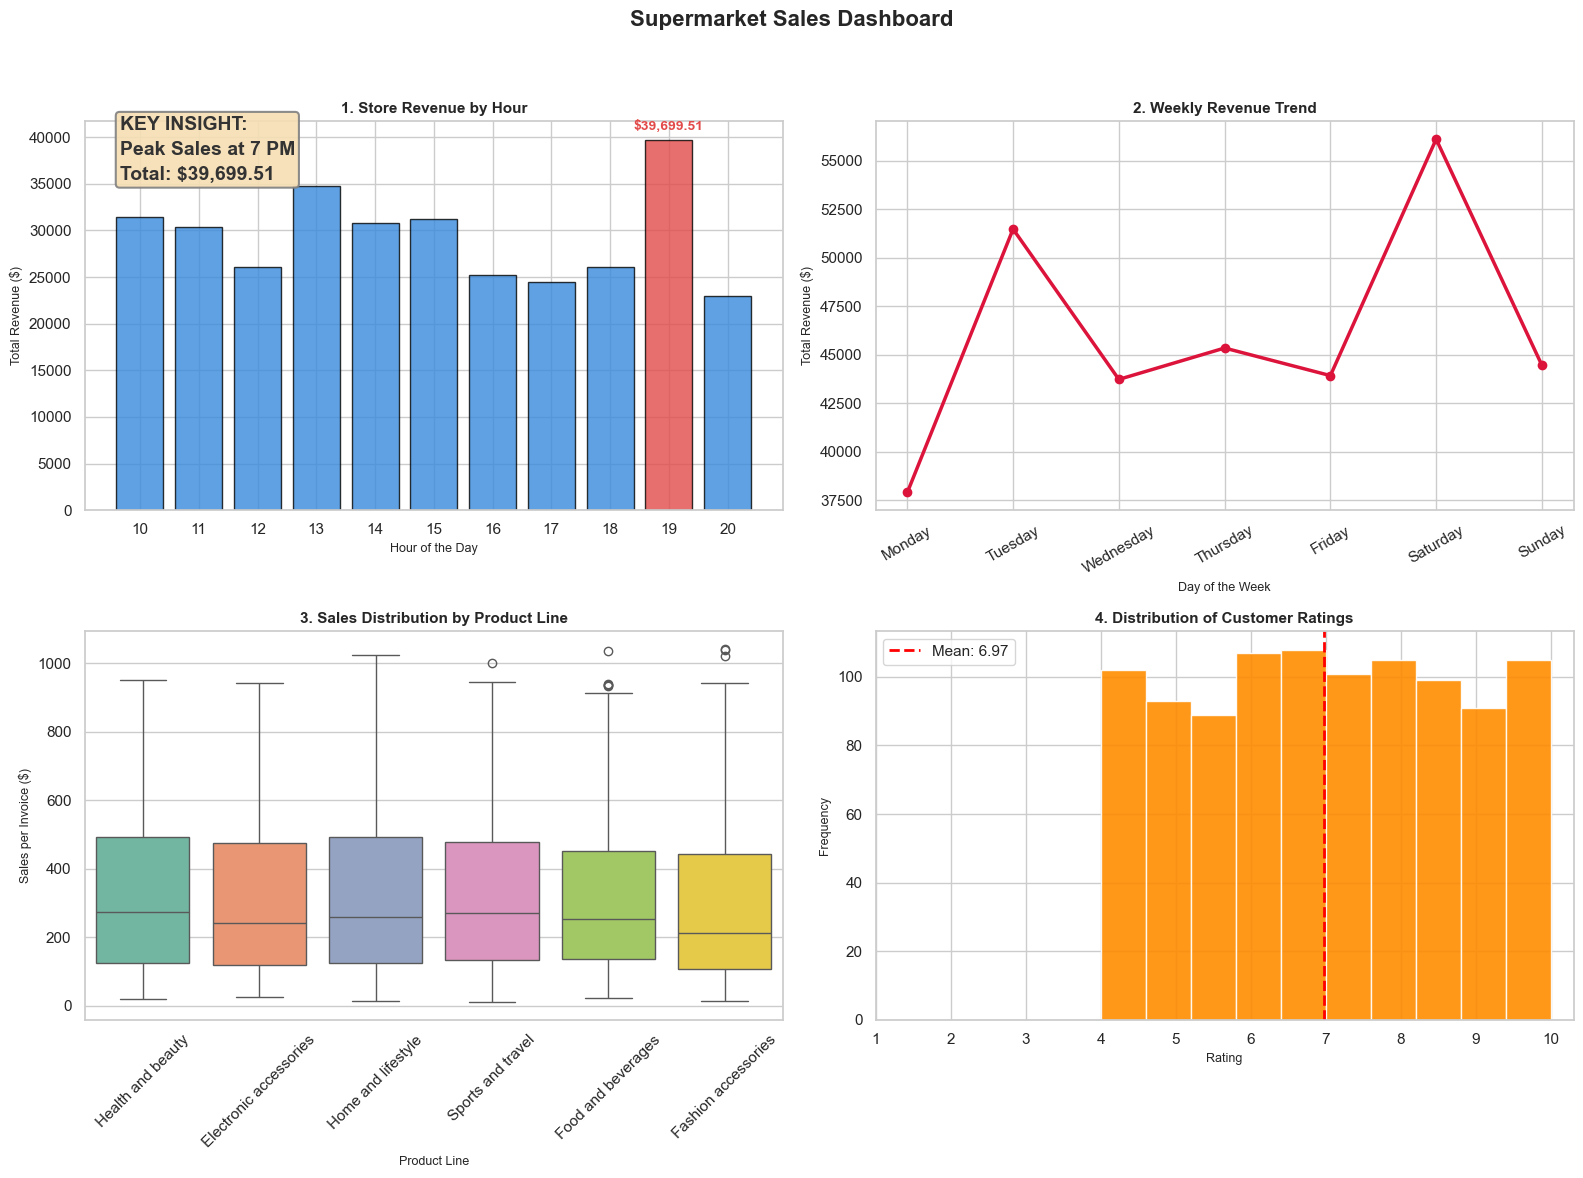

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Global theme
sns.set_theme(style='whitegrid')

# --- DATA PREPARATION ---
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour
hourly_revenue = df.groupby('Hour')['Sales'].sum()
peak_hour = hourly_revenue.idxmax()
peak_val = hourly_revenue.max()

# Peak hour ko 12-hour format mein badalna text box ke liye (e.g., 19 -> 7 PM)
peak_time_str = pd.to_datetime(str(peak_hour), format='%H').strftime('%I %p').lstrip('0')

bar_colors = ['#E24B4A' if h == peak_hour else '#378ADD' for h in hourly_revenue.index]

df['Day_of_Week'] = pd.to_datetime(df['Date']).dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_revenue = df.groupby('Day_of_Week')['Sales'].sum().reindex(day_order)

# --- DASHBOARD LAYOUT (2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
(ax1, ax2), (ax3, ax4) = axes

# MAIN SUPER TITLE
fig.suptitle('Supermarket Sales Dashboard', fontsize=16, fontweight='bold', y=0.98)


# 📊CHART 1: Hourly Sales (Top-Left)
ax1.bar(x=hourly_revenue.index, height=hourly_revenue.values, color=bar_colors, edgecolor='black', alpha=0.8)
ax1.set_title('1. Store Revenue by Hour', fontsize=11, fontweight='bold')
ax1.set_xlabel('Hour of the Day', fontsize=9)
ax1.set_ylabel('Total Revenue ($)', fontsize=9)
ax1.set_xticks(hourly_revenue.index)

# Purani annotation (jo bar ke upar value likhti hai)
ax1.annotate(f'${peak_val:,.2f}', xy=(peak_hour, peak_val), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#E24B4A')

#  UPDATED TEXT BOX: Big fonts aur crisp view ke liye
insight_text = 'KEY INSIGHT:\nPeak Sales at 7 PM\nTotal: $39,699.51'

ax1.text(0.05, 0.85, insight_text, transform=ax1.transAxes, 
         fontsize=14,          # <--- Font size 10 se barha kar 14 kar diya (Bada dikhega)
         fontweight='bold', 
         color='#333333',
         linespacing=1.5,      # <--- Lines ke darmiyan gap barha diya taake khula parha jaye
         bbox=dict(boxstyle='round,pad=0.2', # <--- Padding barha di taake dabba bada ho jaye
                   facecolor='wheat', 
                   alpha=0.9,  # <--- Background ko mazeed solid kiya taake grid lines peeche chup jayen
                   edgecolor='gray', 
                   linewidth=1.5))


# CHART 2: Weekly Sales (Top-Right)
ax2.plot(daily_revenue.index, daily_revenue.values, marker='o', color='crimson', linewidth=2.5)
ax2.set_title('2. Weekly Revenue Trend', fontsize=11, fontweight='bold')
ax2.set_xlabel('Day of the Week', fontsize=9)
ax2.set_ylabel('Total Revenue ($)', fontsize=9)
ax2.tick_params(axis='x', rotation=30)

#  CHART 3: Sales by Product Line (Bottom-Left)
sns.boxplot(data=df, x='Product line', y='Sales', ax=ax3, palette='Set2')
ax3.set_title('3. Sales Distribution by Product Line', fontsize=11, fontweight='bold')
ax3.set_xlabel('Product Line', fontsize=9)
ax3.set_ylabel('Sales per Invoice ($)', fontsize=9)
ax3.tick_params(axis='x', rotation=45)

#  CHART 4: Ratings (Bottom-Right)
ax4.hist(df['Rating'], bins=10, color='darkorange', edgecolor='white', alpha=0.9)
ax4.axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['Rating'].mean():.2f}")
ax4.set_title('4. Distribution of Customer Ratings', fontsize=11, fontweight='bold')
ax4.set_xlabel('Rating', fontsize=9)
ax4.set_ylabel('Frequency', fontsize=9)
ax4.set_xticks(range(1, 11))
ax4.legend(loc='upper left')


# --- CRITICAL ADJUSTMENT FOR SUPTITLE ---
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save and Show
plt.savefig('supermarket_main_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()